In [11]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [12]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [13]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
plotting=True

currently on type general
currently on type cloudy


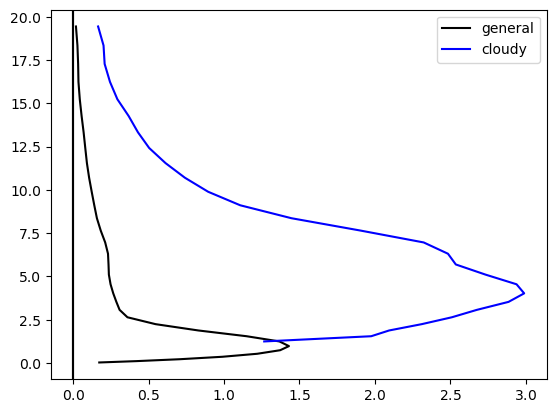

In [18]:
if plotting==True:
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        dir2=dir+'Project_Algorithms/Domain_Profiles/'

        ##########
        # if type == "general":
        #     input_file =dir2+f'job_out/general_eulerian_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5'
        # elif type == "cloudy":
        #     input_file =dir2+f'job_out/cloudy_eulerian_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5'
        if type == "general":
            input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
        ##########
        
        with h5py.File(input_file, 'r') as f:
            if type == "general":
                VMF = np.array(f['profile_VMF_g'])
            elif type == "cloudy":
                VMF = np.array(f['profile_VMF_c'])
        
        
        #Uses Averaged_Profiles Function
        vars = ['VMF'] 
        
        for var in vars:
            globals()[f"out_{var}"] = averaged_profiles(globals()[f"{var}"])
        
        if type=='general':
            color='black'
        elif type=='cloudy':
            color='blue'
    
        plt.plot(out_VMF[:,0],out_VMF[:,1],color=color,label=type)
        plt.axvline(0,color='k')
        ax = plt.gca()
        apply_scientific_notation([ax])
        
        plt.legend()

In [19]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

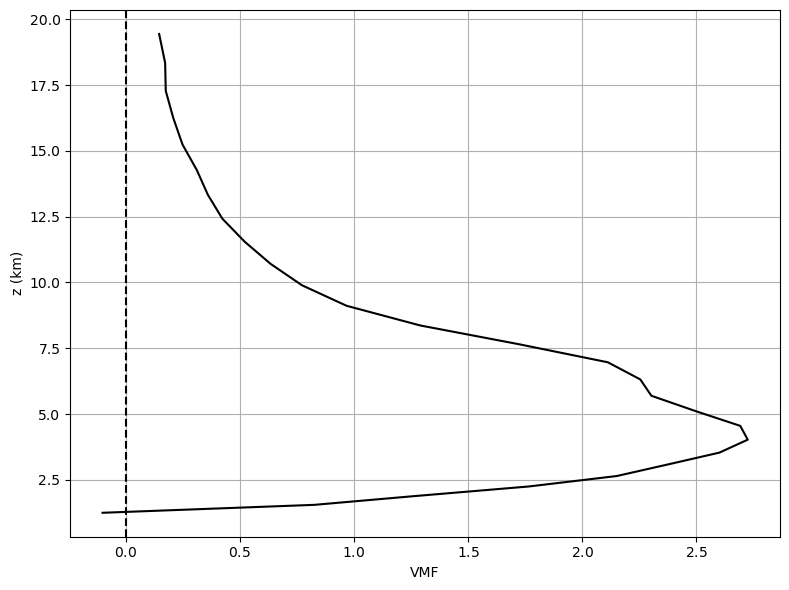

In [20]:
if plotting==True:
    #Plotting Differences
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    label=1
    
        
    def get_data(type):
        dir2=dir+'Project_Algorithms/Domain_Profiles/'
        ##########
        # if type == "general":
        #     input_file =dir2+f'job_out/general_eulerian_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5'
        # elif type == "cloudy":
        #     input_file =dir2+f'job_out/cloudy_eulerian_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5'
        if type == "general":
            input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
        ##########
    
        with h5py.File(input_file, 'r') as f:
            if type == "general":
                VMF = np.array(f['profile_VMF_g'])
            elif type == "cloudy":
                VMF = np.array(f['profile_VMF_c'])
        return VMF
    
        
    def diff_plotting():
        #setting up figure
        fig, axis = plt.subplots(1, 1, figsize=(8, 6))
        # fig.suptitle("")
        # ax1= axs.flatten()
    
        #the plotting
        vars = ['VMF'] 
        xlabels = ['VMF'] 
        for xlabel,var in zip(xlabels,vars):
    
            #get profile
            types=['cloudy','general']
            out_var_one=get_data(types[0])
            out_var_two=get_data(types[1])
    
            #finding where cloudy updraft count goes below 10
            cutofflow=np.where(out_var_one[:,1]>10)[0][0]
            cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
           
            #averaging
            out_var_diff=average_difference(out_var_one,out_var_two)
            
            axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
            axis.axvline(0,color='k',linestyle='dashed')
            # axis.set_ylim(bottom=0,top=20)
            ## axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
            #labeling
            axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
            axis.grid(True)
            # axis.legend(fontsize='small') #only adds legend at final variable
    
            if axis==axis:
                apply_scientific_notation([axis])
    
            # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        plt.tight_layout()
    
    diff_plotting()